# Jaguar Re-Identification - Baseline Models

**Models**: Linear (Flatten + Dense) and MLP  
**Hyperparameter study**: optimizer, learning rate, activation  
**Submission**: embeddings + cosine similarity on test pairs

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: []


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR = os.path.join(DATA_DIR, 'cleaned')
TRAIN_IMG_DIR = os.path.join(CLEANED_DIR, 'train')
TEST_IMG_DIR = os.path.join(CLEANED_DIR, 'test')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')

LOG_DIR = r'C:\tf\logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Data loading

In [3]:
train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_split.csv'))
val_df = pd.read_csv(os.path.join(CLEANED_DIR, 'val_split.csv'))
test_pairs_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"Test pairs: {len(test_pairs_df)}")
print(f"Classes: {NUM_CLASSES}")

Train: 1516 images
Val:   379 images
Test pairs: 137270
Classes: 31


In [4]:
def load_images_from_df(df, img_dir):
    images, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(os.path.join(img_dir, row['filename'])).convert('RGB')
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

print("Loading train images...")
X_train, y_train = load_images_from_df(train_df, TRAIN_IMG_DIR)
print("Loading val images...")
X_val, y_val = load_images_from_df(val_df, TRAIN_IMG_DIR)

print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Pixel range: [{X_train.min():.3f}, {X_train.max():.3f}]")

Loading train images...
Loading val images...

X_train: (1516, 224, 224, 3), X_val: (379, 224, 224, 3)
Pixel range: [0.000, 1.000]


In [5]:
def load_test_images(img_dir):
    test_images = {}
    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            test_images[fname] = np.array(img, dtype=np.float32) / 255.0
    return test_images

print("Loading test images...")
test_images = load_test_images(TEST_IMG_DIR)
print(f"Loaded {len(test_images)} test images")

Loading test images...
Loaded 371 test images


## 2. Linear model (baseline 1)

In [6]:
def build_linear_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='linear_model')
    return model

linear_model = build_linear_model()
linear_model.summary()

Model: "linear_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │     4,666,399 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,666,399 (17.80 MB)

 Trainable params: 4,666,399 (17.80 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
linear_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

linear_log_dir = os.path.join(LOG_DIR, 'linear_model', datetime.now().strftime('%Y%m%d-%H%M%S'))

linear_history = linear_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.TensorBoard(log_dir=linear_log_dir, histogram_freq=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.0989 - loss: 12.6032 - val_accuracy: 0.2612 - val_loss: 5.2105
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3384 - loss: 3.4953 - val_accuracy: 0.4011 - val_loss: 2.6461
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4888 - loss: 2.1910 - val_accuracy: 0.4142 - val_loss: 2.4881
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5864 - loss: 1.7671 - val_accuracy: 0.4301 - val_loss: 2.8034
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6095 - loss: 1.8206 - val_accuracy: 0.4169 - val_loss: 2.4684
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6590 - loss: 1.3700 - val_accuracy: 0.5303 - val_loss: 2.1529
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7342 - loss: 1.0921 - val_accuracy: 0.4855 - val_loss: 2.6058
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7579 - loss: 1.0295 - val_accuracy: 0.4301 - 

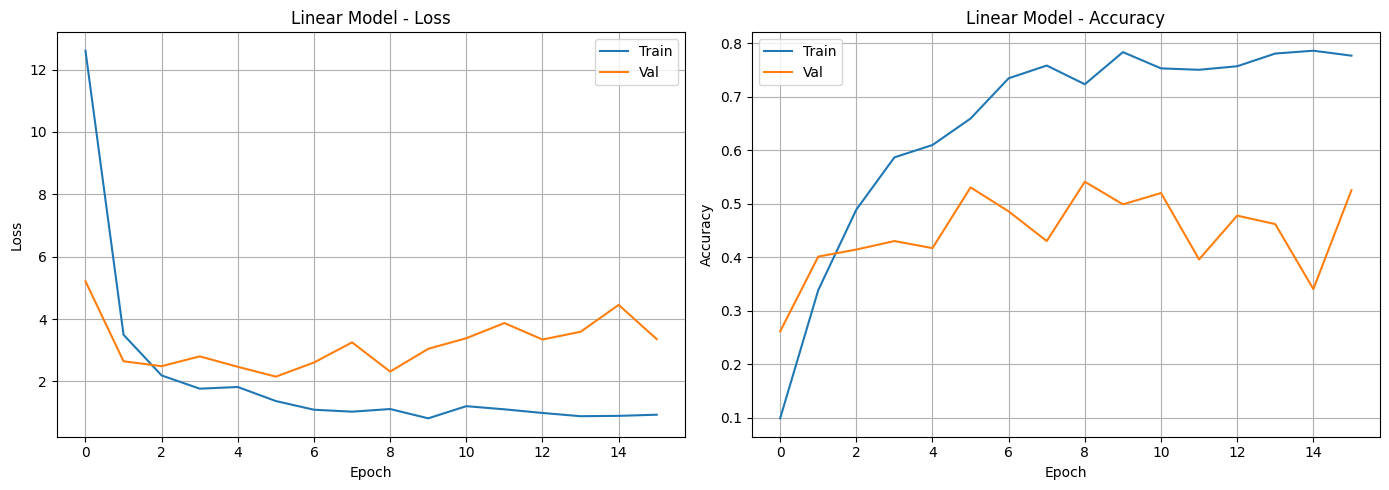

In [8]:
def plot_history(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['accuracy'], label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(linear_history, 'Linear Model',
             os.path.join(OUTPUT_DIR, 'linear_model_history.png'))

In [9]:
linear_train_loss, linear_train_acc = linear_model.evaluate(X_train, y_train, verbose=0)
linear_val_loss, linear_val_acc = linear_model.evaluate(X_val, y_val, verbose=0)

print(f"Linear Model:")
print(f"  Train - Loss: {linear_train_loss:.4f}, Acc: {linear_train_acc:.4f}")
print(f"  Val   - Loss: {linear_val_loss:.4f}, Acc: {linear_val_acc:.4f}")

Linear Model:
  Train - Loss: 1.0978, Acc: 0.7375
  Val   - Loss: 2.1529, Acc: 0.5303


## 3. MLP model (baseline 2)

In [ ]:
def build_mlp_model(hidden_units=[512, 256], activation='relu'):
    model = keras.Sequential(name='mlp_model')
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(layers.Flatten())
    for units in hidden_units:
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

mlp_model = build_mlp_model()
mlp_model.summary()

In [11]:
mlp_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp_log_dir = os.path.join(LOG_DIR, 'mlp_model', datetime.now().strftime('%Y%m%d-%H%M%S'))

mlp_history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.TensorBoard(log_dir=mlp_log_dir, histogram_freq=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.0462 - loss: 6.9891 - val_accuracy: 0.0580 - val_loss: 3.3297
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 35s 676ms/step - accuracy: 0.0706 - loss: 3.4055 - val_accuracy: 0.0528 - val_loss: 3.3982
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 33s 652ms/step - accuracy: 0.0759 - loss: 3.3809 - val_accuracy: 0.1266 - val_loss: 3.3778
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 643ms/step - accuracy: 0.0983 - loss: 3.3285 - val_accuracy: 0.0950 - val_loss: 3.2480
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 635ms/step - accuracy: 0.0950 - loss: 3.3320 - val_accuracy: 0.0950 - val_loss: 3.2112
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 629ms/step - accuracy: 0.0891 - loss: 3.2738 - val_accuracy: 0.1293 - val_loss: 3.2488
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 636ms/step - accuracy: 0.0976 - loss: 3.2466 - val_accuracy: 0.0897 - val_loss: 3.1434
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 635ms/step - accuracy: 0.0943 - loss: 3.2575 - val_accurac

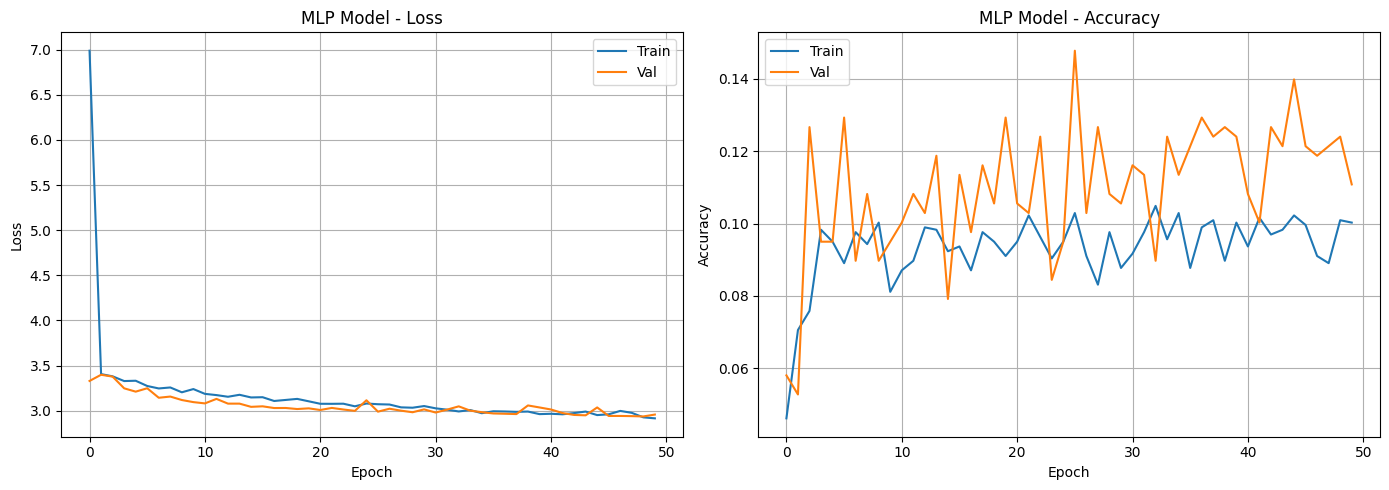

In [12]:
plot_history(mlp_history, 'MLP Model',
             os.path.join(OUTPUT_DIR, 'mlp_model_history.png'))

In [13]:
mlp_train_loss, mlp_train_acc = mlp_model.evaluate(X_train, y_train, verbose=0)
mlp_val_loss, mlp_val_acc = mlp_model.evaluate(X_val, y_val, verbose=0)

print(f"MLP Model:")
print(f"  Train - Loss: {mlp_train_loss:.4f}, Acc: {mlp_train_acc:.4f}")
print(f"  Val   - Loss: {mlp_val_loss:.4f}, Acc: {mlp_val_acc:.4f}")

MLP Model:
  Train - Loss: 2.7786, Acc: 0.1352
  Val   - Loss: 2.9363, Acc: 0.1240


## 4. Hyperparameter study

In [ ]:
def fit_model(name, model, optimizer, log_subdir, epochs=30, patience=8):
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, log_subdir, name)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.TensorBoard(log_dir=log_dir),
            callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        ],
        verbose=0
    )
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"  {name}: val_acc={val_acc:.4f}, val_loss={val_loss:.4f}")
    return {'val_loss': val_loss, 'val_acc': val_acc}, hist.history

In [ ]:
optimizer_configs = {
    'SGD': optimizers.SGD(learning_rate=1e-3),
    'SGD_momentum': optimizers.SGD(learning_rate=1e-3, momentum=0.9),
    'RMSProp': optimizers.RMSprop(learning_rate=1e-3),
    'Adam': optimizers.Adam(learning_rate=1e-3),
}

opt_runs = {}
print("=== Optimizers (lr=1e-3, relu) ===")
for name, opt in optimizer_configs.items():
    m = build_mlp_model(hidden_units=[256, 128])
    res, hist = fit_model(name, m, opt, 'hp_optimizer')
    opt_runs[name] = {**res, 'hist': hist}

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, run in opt_runs.items():
    axes[0].plot(run['hist']['val_loss'], label=name)
    axes[1].plot(run['hist']['val_accuracy'], label=name)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Optimizers - val loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Optimizers - val accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hp_optimizer_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
lr_runs = {}
print("=== Learning rates (Adam, relu) ===")
for lr in [1e-2, 1e-3, 1e-4]:
    name = f"lr={lr}"
    m = build_mlp_model(hidden_units=[256, 128])
    res, hist = fit_model(name, m, optimizers.Adam(learning_rate=lr), 'hp_lr')
    lr_runs[name] = {**res, 'hist': hist}

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, run in lr_runs.items():
    axes[0].plot(run['hist']['val_loss'], label=name)
    axes[1].plot(run['hist']['val_accuracy'], label=name)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Learning rate - val loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Learning rate - val accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hp_learning_rate_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
act_runs = {}
print("=== Activations (Adam, lr=1e-3) ===")
for act in ['relu', 'sigmoid', 'tanh']:
    m = build_mlp_model(hidden_units=[256, 128], activation=act)
    res, hist = fit_model(act, m, optimizers.Adam(learning_rate=1e-3), 'hp_activation')
    act_runs[act] = {**res, 'hist': hist}

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, run in act_runs.items():
    axes[0].plot(run['hist']['val_loss'], label=name)
    axes[1].plot(run['hist']['val_accuracy'], label=name)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Activation - val loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Activation - val accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hp_activation_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Results summary

In [ ]:
rows = [
    {'Experiment': 'Linear Model',             'Val Accuracy': linear_val_acc, 'Val Loss': linear_val_loss},
    {'Experiment': 'MLP (Adam, lr=1e-4, relu)', 'Val Accuracy': mlp_val_acc,    'Val Loss': mlp_val_loss},
]
for name, run in opt_runs.items():
    rows.append({'Experiment': f'opt={name}', 'Val Accuracy': run['val_acc'], 'Val Loss': run['val_loss']})
for name, run in lr_runs.items():
    rows.append({'Experiment': name,          'Val Accuracy': run['val_acc'], 'Val Loss': run['val_loss']})
for name, run in act_runs.items():
    rows.append({'Experiment': f'act={name}', 'Val Accuracy': run['val_acc'], 'Val Loss': run['val_loss']})

results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

## 6. Kaggle submission

In [ ]:
final_model = build_mlp_model(hidden_units=[512, 256], activation='relu')
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

all_train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_clean.csv'))
print("Loading all training images...")
X_all, y_all = load_images_from_df(all_train_df, TRAIN_IMG_DIR)

final_log_dir = os.path.join(LOG_DIR, 'final_mlp', datetime.now().strftime('%Y%m%d-%H%M%S'))
final_history = final_model.fit(
    X_all, y_all,
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=[callbacks.TensorBoard(log_dir=final_log_dir)],
    verbose=1
)

print(f"\nFinal train accuracy: {final_history.history['accuracy'][-1]:.4f}")

In [ ]:
inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x)

test_filenames = sorted(test_images.keys())
test_array = np.array([test_images[f] for f in test_filenames])

test_embeddings = embedding_model.predict(test_array, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embeddings shape: {test_embeddings.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}

In [ ]:
query_idx = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.sum(
    test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx],
    axis=1
)
similarities = np.clip(similarities, 0, 1)

print(f"Similarities: {len(similarities)} pairs")
print(f"Min: {similarities.min():.4f}, Max: {similarities.max():.4f}, Mean: {similarities.mean():.4f}")

In [ ]:
submission = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

submission_path = os.path.join(SUBMISSION_DIR, 'submission_baseline_mlp.csv')
submission.to_csv(submission_path, index=False)

print(f"Saved: {submission_path}")
display(submission.head(10))

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel('Similarity score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of predicted similarity scores (MLP baseline)')
ax.axvline(x=similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'similarity_distribution_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

In [ ]:
print(f"""
Linear:  train={linear_train_acc:.4f}, val={linear_val_acc:.4f}
MLP:     train={mlp_train_acc:.4f}, val={mlp_val_acc:.4f}

Best HP: {results_df.iloc[0]['Experiment']} (val_acc={results_df.iloc[0]['Val Accuracy']:.4f})

Submission -> submissions/submission_baseline_mlp.csv
TensorBoard -> tensorboard --logdir={LOG_DIR}
""")